<a href="https://colab.research.google.com/github/Arczisork/Sztuczna-inteligencja/blob/main/sztuczna_lab_zad3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [41]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
print(tf.__version__)



2.19.0


In [42]:
observations = 100000
xs = np.random.uniform(low=-10,high=10,size=(observations,1))
zs = np.random.uniform(low=-10,high=10,size=(observations,1))
inputs=np.column_stack((xs,zs))
print(inputs.shape)


(100000, 2)


In [43]:
noise = np.random.uniform(low=-1,high=1,size=(observations,1))
targets = 22*xs - 31*zs + 15 + noise
np.savez('TF_dataset',inputs=inputs,targets=targets)
print(targets.shape)


(100000, 1)


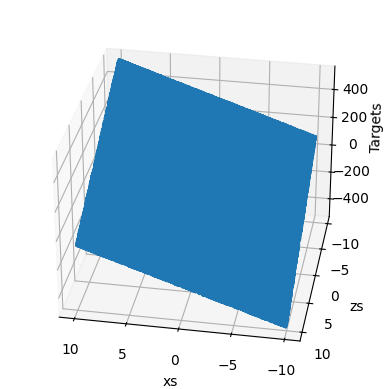

In [44]:

targets = targets.reshape(observations,)
xs = xs.reshape(observations,)
zs = zs.reshape(observations,)
fig = plt.figure()
ax = fig.add_subplot(111,projection='3d')
ax.plot(xs,zs,targets)
ax.set_xlabel('xs')
ax.set_ylabel('zs')
ax.set_zlabel('Targets')
ax.view_init(azim=100)
plt.show()

In [45]:
init_range= 0.1
weights = np.random.uniform(low=-init_range,high=init_range,size=(2,1))
biases = np.random.uniform(low=-init_range,high=init_range,size=1)
print(weights,biases)


[[ 0.01045752]
 [-0.07385647]] [0.08414976]


In [46]:
targets = targets.reshape(observations,1)
eta = 0.01
for i in range (100):
  outputs = np.dot(inputs,weights) + biases
  deltas = outputs - targets

  loss = np.sum(deltas **2)/2/observations
  print(loss)

  deltas_scaled = deltas/observations
  weights = weights - eta * np.dot(inputs.T,deltas_scaled)
  biases = biases - eta * np.sum(deltas_scaled)


24049.556717043968
10768.772943172378
4853.903659381388
2218.9407136075847
1044.4825408902207
520.3873451845652
285.9130402151232
180.42608182214335
132.39780664626284
109.9766959644711
98.9790296192494
93.08842372584498
89.49178797405023
86.93604986090352
84.86282238948387
83.02307259626758
81.30553262812448
79.6602902235264
78.06476280748876
76.50854524125529
74.98666217284843
73.4965630559231
72.0367838360727
70.60635083620201
69.20451516112219
67.83063429277769
66.48411923593534
65.16441085793046
63.870969231922935
62.603268773465174
61.36079595940039
60.14304819907069
58.94953322094745
57.77976869100813
56.63328193647737
55.50960971860944
54.408298029383886
53.328901900883835
52.27098522231427
51.234120562373235
50.21788899592174
49.221879934443386
48.24569096002669
47.28892766272134
46.35120348115896
45.43213954635911
44.53136452865079
43.64851448764098
42.78323272517097
41.93516964119919
41.1039825925519
40.289335754484796
39.490899984999544
38.708352691860874
37.94137770225893


In [47]:
print(weights, biases)

[[ 21.9981516 ]
 [-30.99541102]] [9.5326417]


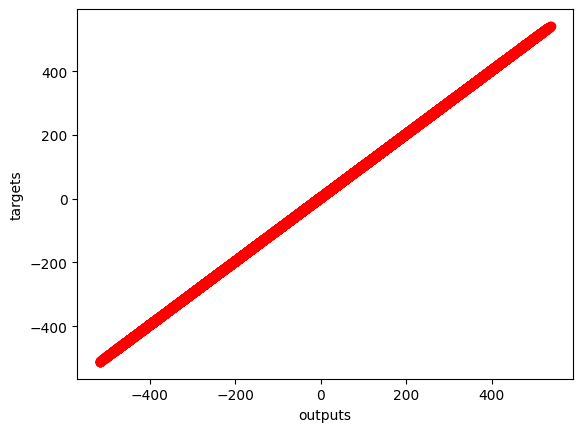

In [48]:
plt.scatter(outputs, targets, color='red')



plt.xlabel('outputs')
plt.ylabel('targets')
plt.show()